# Just plotting the token wise accuracy

In [59]:
import json
import matplotlib.pyplot as plt
import base64
import numpy as np
import sys

sys.path.append("../src/")
import utils

In [60]:
plt.rcParams.update({
    # Figure size - ICML typically uses two-column format
    'figure.figsize': (3.25, 2.5),  # Single column width
    # 'figure.figsize': (6.75, 2.5),  # Double column width
    
    # Font sizes
    'font.size': 10,           # Base font size
    'axes.labelsize': 11,      # X and Y labels
    'axes.titlesize': 11,      # Title
    'xtick.labelsize': 9,      # X tick labels
    'ytick.labelsize': 9,      # Y tick labels
    'legend.fontsize': 8,      # Legend
    
    # Font family
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    
    # Use LaTeX for text rendering (optional but recommended)
    'text.usetex': False,  # Set to True if you have LaTeX installed
    
    # Line widths
    'axes.linewidth': 0.5,
    'lines.linewidth': 1.5,
    'patch.linewidth': 0.5,
    
    # Grid
    'grid.linewidth': 0.5,
    'grid.alpha': 0.3,
    
    # Ticks
    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
    'xtick.major.size': 3,
    'ytick.major.size': 3,
    
    # Legend
    'legend.frameon': True,
    'legend.framealpha': 0.8,
    'legend.fancybox': False,
    'legend.edgecolor': 'black',
    
    # Save settings
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05,
    'savefig.format': 'pdf',  # PDF is preferred for publications
})



In [61]:
root_folder = "data/"
name_template = "accuracy_metrics_mult"

runs = []
for i in [2, 3, 5, 7, 10, 15, 20]:
    file_name = f"{root_folder}{name_template}{i}.json"
    print("load file:", file_name)
    with open(file_name, "r", encoding="utf-8") as f:
        data = json.load(f)
        dtype = np.dtype(data[3]["y"]["dtype"])
        raw = base64.b64decode(data[3]["y"]["bdata"])
        arry = np.frombuffer(raw, dtype=dtype)

        print("num classes:", i)
        print("array sample:", arry[:10])

        runs.append({
            "num_classes": i,
            "x": data[3]["x"],
            "y": arry
        })


load file: data/accuracy_metrics_mult2.json
num classes: 2
array sample: [0.5        0.5        0.5        0.50131579 0.5        0.5
 0.50131579 0.51184211 0.51710526 0.53947368]
load file: data/accuracy_metrics_mult3.json
num classes: 3
array sample: [0.33333333 0.33333333 0.33333333 0.33333333 0.33333333 0.33461538
 0.33461538 0.34102564 0.36794872 0.38333333]
load file: data/accuracy_metrics_mult5.json
num classes: 5
array sample: [0.2     0.19875 0.2     0.2     0.20125 0.2025  0.2     0.2125  0.21875
 0.23375]
load file: data/accuracy_metrics_mult7.json
num classes: 7
array sample: [0.14285714 0.14285714 0.14285714 0.14411028 0.14285714 0.14285714
 0.14285714 0.1641604  0.1641604  0.19172932]
load file: data/accuracy_metrics_mult10.json
num classes: 10
array sample: [0.1     0.1     0.10125 0.1     0.1     0.09875 0.1     0.10875 0.13375
 0.14375]
load file: data/accuracy_metrics_mult15.json
num classes: 15
array sample: [0.06666667 0.06666667 0.06540881 0.06540881 0.06666667 0.06

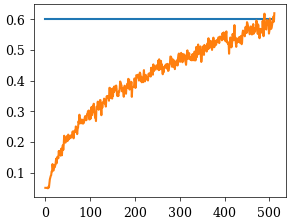

In [62]:
plt.plot(data[1]["x"], data[1]["y"])
plt.plot(data[3]["x"], arry)

2 [0.5        0.5        0.5        0.50131579 0.5        0.5
 0.50131579 0.51184211 0.51710526 0.53947368 0.55921053 0.56710526
 0.58157895 0.61052632 0.60657895 0.62631579 0.65131579 0.65131579
 0.68289474 0.66184211 0.68684211 0.67763158 0.68684211 0.68289474
 0.71578947 0.70394737 0.69605263 0.73421053 0.73815789 0.75263158
 0.74078947 0.74078947 0.74473684 0.74342105 0.75789474 0.75
 0.76578947 0.75657895 0.73552632 0.76184211 0.77105263 0.78157895
 0.77763158 0.77631579 0.775      0.76973684 0.76184211 0.77105263
 0.78552632 0.79342105 0.77763158 0.78684211 0.79841897 0.78656126
 0.7773386  0.7826087  0.7654809  0.7826087  0.7773386  0.79578393
 0.7997365  0.7944664  0.81422925 0.81291173 0.80079156 0.7823219
 0.77968338 0.8060686  0.81002639 0.7994723  0.79815303 0.80211082
 0.79287599 0.82058047 0.79419525 0.81266491 0.80343008 0.79419525
 0.80581242 0.80845443 0.80184941 0.81902246 0.80317041 0.81373844
 0.82166446 0.84015852 0.84676354 0.84147952 0.82298547 0.83619551
 0.8388

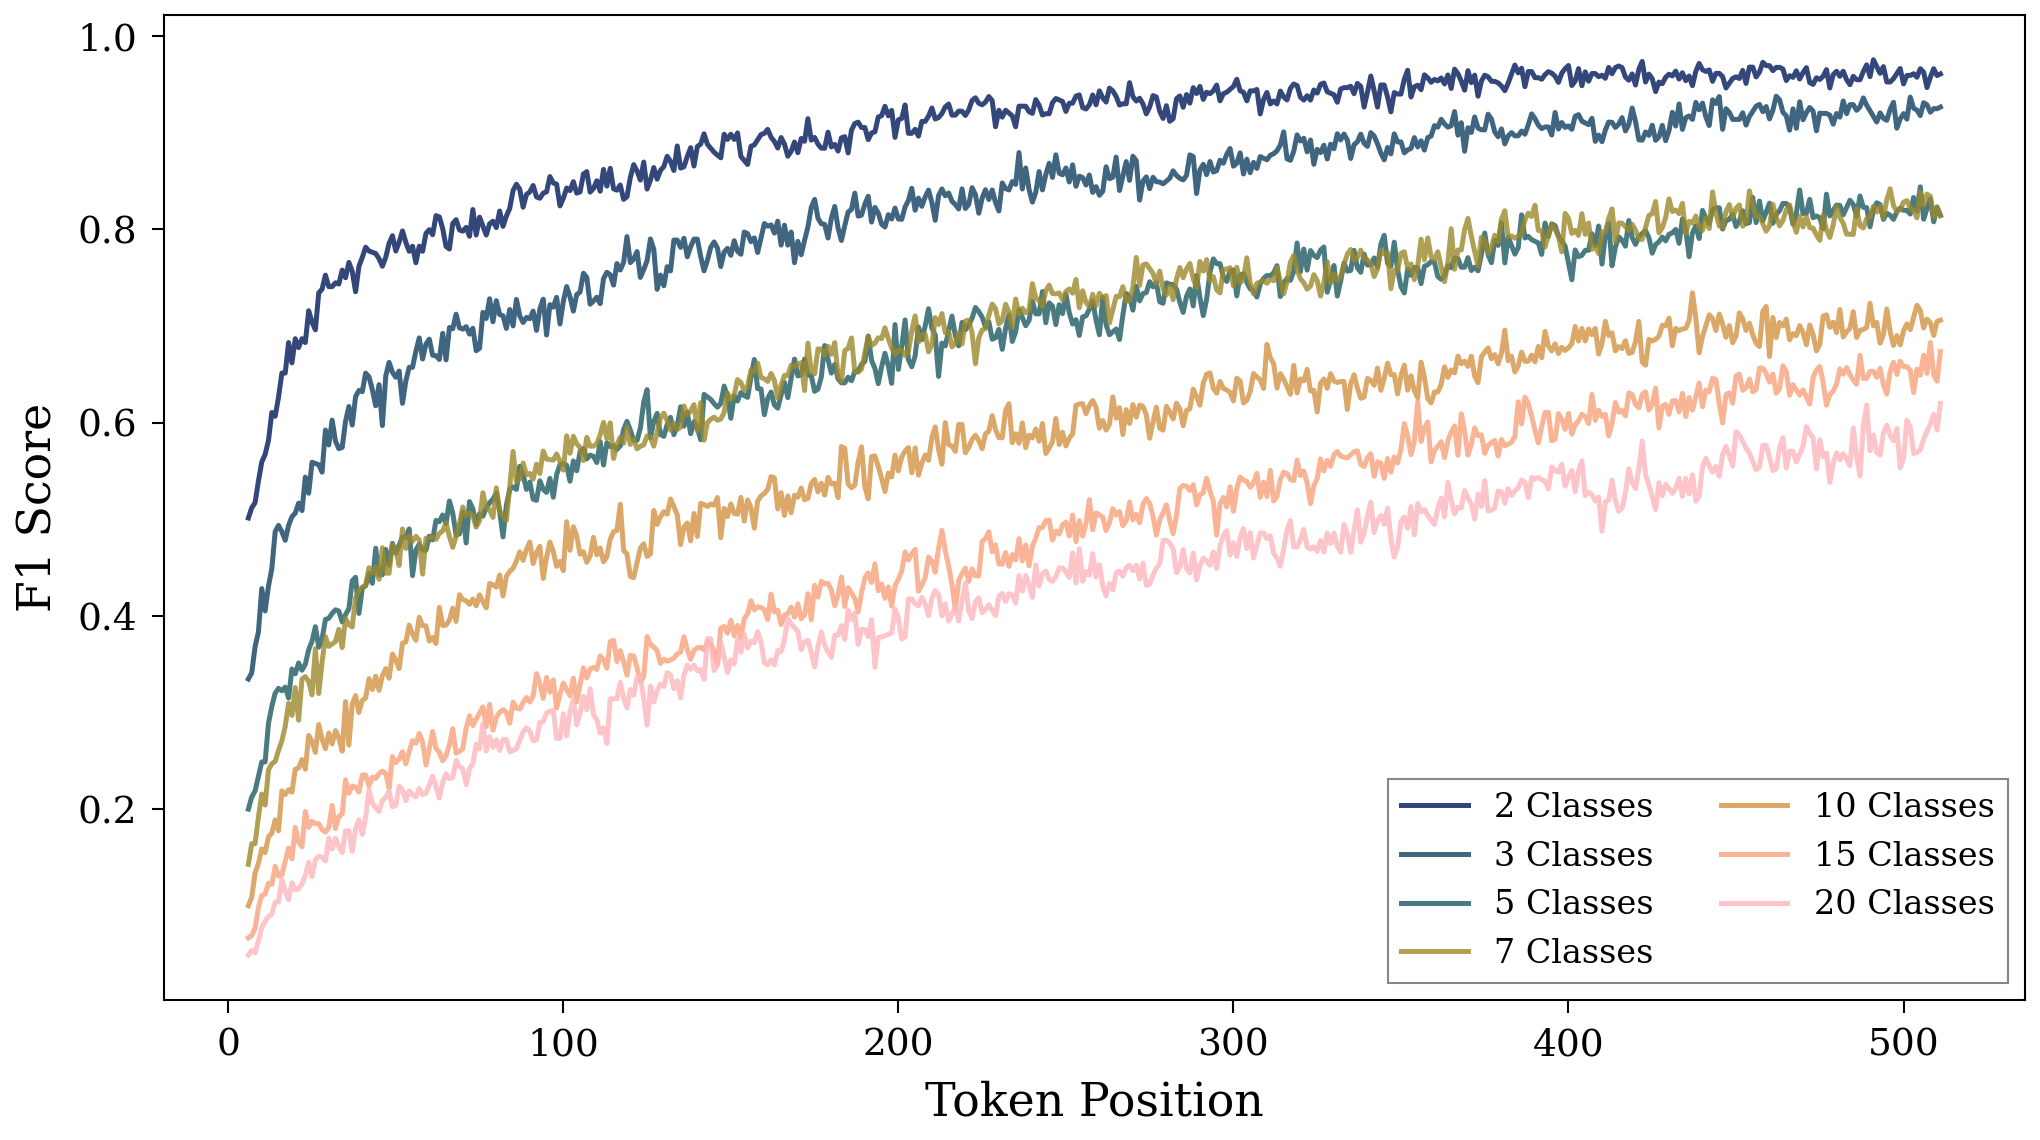

In [67]:

color_palette = [utils.batlow10_colors[i] for i in [0, 1, 2, 5, 6, 7, 8, 9]] #batlow_categorical_colors

fig, ax = plt.subplots(figsize=(7, 4), dpi=300)

# Plot individual runs with transparency
for i, run in enumerate(runs):
    print(run["num_classes"], run["y"])
    ax.plot(run["x"][6:], run["y"][6:], color=color_palette[i], alpha=0.8, linewidth=1.2, 
            label=f'{run["num_classes"]} Classes', zorder=2)

# Calculate and plot mean and standard deviation
# runs_array = np.array([run["y"] for run in runs])
# mean_f1 = np.mean(runs_array, axis=0)
# std_f1 = np.std(runs_array, axis=0)

# ax.plot(token_positions, mean_f1, color='black', linewidth=2.5, 
#         label='Mean', zorder=10)
# ax.fill_between(token_positions, mean_f1 - std_f1, mean_f1 + std_f1, 
#                 color='black', alpha=0.15, label='±1 std', zorder=5)

# Formatting
ax.set_xlabel('Token Position', fontweight='normal')
ax.set_ylabel('F1 Score', fontweight='normal')
# ax.set_title('Test Accuracy across Token Positions', fontweight='bold', pad=10)

# Grid
# ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
# ax.set_axisbelow(True)

# Legend
ax.legend(loc='best', framealpha=0.95, edgecolor='gray', ncol=2)

# Set y-axis limits with some padding
# y_min = np.min(runs_array) - 0.05
# y_max = np.max(runs_array) + 0.05
# ax.set_ylim([max(0, y_min), min(1, y_max)])

# Spines
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)
# ax.spines['left'].set_linewidth(0.8)
# ax.spines['bottom'].set_linewidth(0.8)

# Tight layout
plt.tight_layout()

# Save in multiple formats
plt.savefig('token-wise-accuracy.pdf', dpi=300, bbox_inches='tight')
plt.savefig('token-wise-accuracy.png', dpi=300, bbox_inches='tight')
